<font size="+3"><strong>3.5. Air Quality in Dar es Salaam 🇹🇿</strong></font>

In [30]:
import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [76]:
# Import libraries here

import inspect
import time
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns
from IPython.display import VimeoVideo
from pymongo import MongoClient
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.ar_model import AutoReg


# Prepare Data

## Connect

<div style="padding: 1em; border: 1px solid #f0ad4e; border-left: 6px solid #f0ad4e; background-color: #fcf8e3; color: #8a6d3b; border-radius: 4px;">

<strong>🛠️ Instruction:</strong> Locate the IP address of the machine running MongoDB and assign it to the variable <code>host</code>. Make sure to use a <strong>string</strong> (i.e., wrap the IP in quotes).<br><br>

<strong>⚠️ Note:</strong> The IP address is <strong>dynamic</strong> — it may change every time you start the lab. Always check the current IP before proceeding.

</div>

<img src="../images/mongo_ip.png" alt="MongoDB" width="600"/>


In [77]:
host = "192.124.184.2"

**Task 3.5.1**

In [78]:
from pymongo import MongoClient

# Instantiate a MongoClient with host and port
client = MongoClient(host=host, port=27017)

# Connect to the air-quality database
db = client["air-quality"]

# Assign the dar-es-salaam collection to variable dar
dar = db["dar-es-salaam"]

## Explore

**Task 3.5.2**

In [79]:
# Extract all unique sensor sites from metadata
sites = dar.distinct("metadata.site")
sites

[23, 11]

**Task 3.5.3**

In [80]:
# Group by sensor_site and calculate total readings count
result = dar.aggregate(
    [
        {
            "$group": {
                "_id": "$metadata.site", 
                "count": {"$sum": 1}
            }
        }
    ]
)
readings_per_site = list(result)
readings_per_site

[{'_id': 23, 'count': 60020}, {'_id': 11, 'count': 173242}]

## Import

**Task 3.5.4**

In [81]:
def wrangle(collection):
    # 1. Extract PM2.5 readings for site 11 (Dar es Salaam) using 'P2' field
    results = collection.find(
        {"metadata.site": 11, "metadata.measurement": "P2"},
        projection={"P2": 1, "timestamp": 1, "_id": 0}
    )
    
    # Read results into a pandas DataFrame
    df = pd.DataFrame(list(results))
    
    # Set timestamp as index
    df.set_index("timestamp", inplace=True)
    df.index = pd.to_datetime(df.index)
    
    # 2. Localize and convert timezone to Africa/Dar_es_Salaam
    df.index = df.index.tz_localize("UTC").tz_convert("Africa/Dar_es_Salaam")
    
    # 3. Remove outlier PM2.5 readings that are above 100
    df = df[df["P2"] <= 100]
    
    # 4 & 5. Resample to 1-hour mean, forward-fill missing values, and return Series y
    y = df["P2"].resample("1H").mean().ffill()
    
    return y
    

Use your `wrangle` function to query the `dar` collection and return your cleaned results.

In [82]:
# Use your wrangle function to query the dar collection
y = wrangle(dar)
print(type(y))

<class 'pandas.core.series.Series'>


## Explore Some More

**Task 3.5.5**

Text(0.5, 1.0, 'Dar es Salaam PM2.5 Levels')

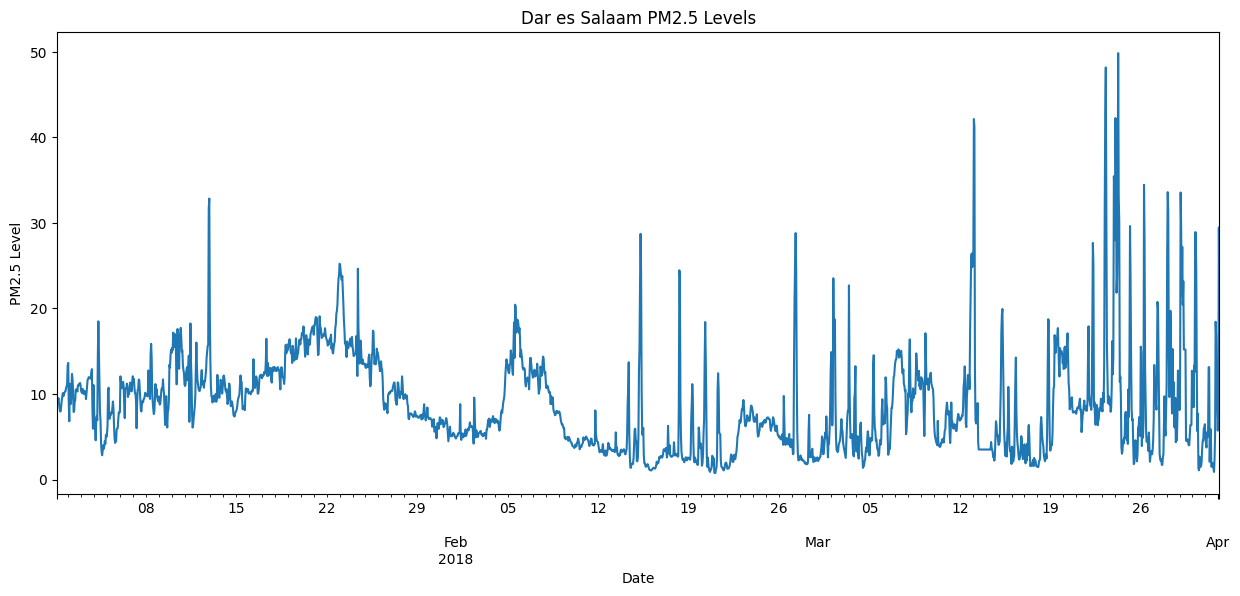

In [83]:
fig, ax = plt.subplots(figsize=(15, 6))

# use ax=ax in your plot


y.plot(ax=ax)

# Set labels and title exactly as required by the assignment
ax.set_xlabel("Date")
ax.set_ylabel("PM2.5 Level")
ax.set_title("Dar es Salaam PM2.5 Levels")



**Task 3.5.6**

Text(0.5, 1.0, 'Dar es Salaam PM2.5 Levels, 7-Day Rolling Average')

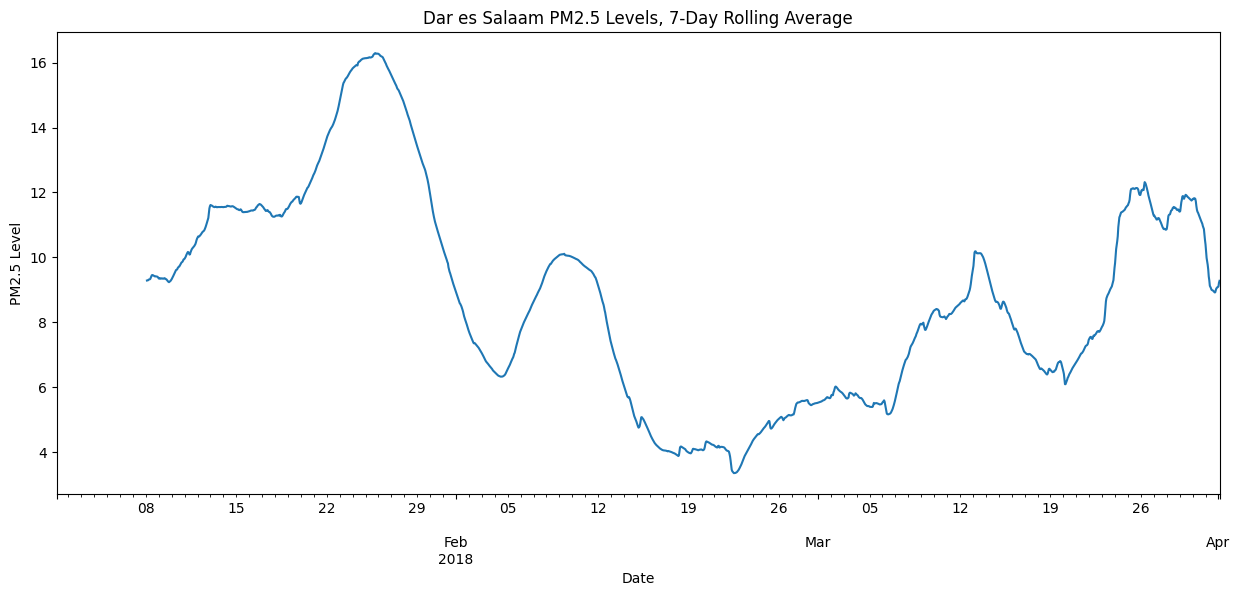

In [84]:
fig, ax = plt.subplots(figsize=(15, 6))

# use ax=ax in your plot
y.rolling(168).mean().plot(ax=ax)
ax.set_xlabel("Date")
ax.set_ylabel("PM2.5 Level")
ax.set_title("Dar es Salaam PM2.5 Levels, 7-Day Rolling Average")


**Task 3.5.7**

Text(0.5, 1.0, 'Dar es Salaam PM2.5 Readings, ACF')

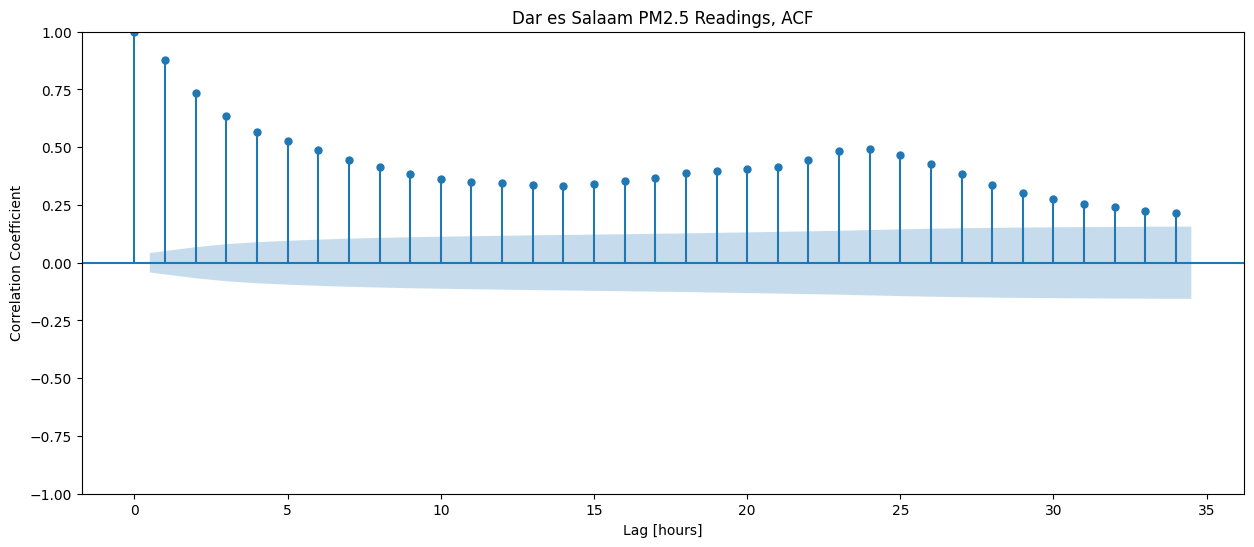

In [85]:
fig, ax = plt.subplots(figsize=(15, 6))

# use ax=ax in your plot
plot_acf(y, ax=ax)
ax.set_xlabel("Lag [hours]")
ax.set_ylabel("Correlation Coefficient")
ax.set_title("Dar es Salaam PM2.5 Readings, ACF")


**Task 3.5.8**

Text(0.5, 1.0, 'Dar es Salaam PM2.5 Readings, PACF')

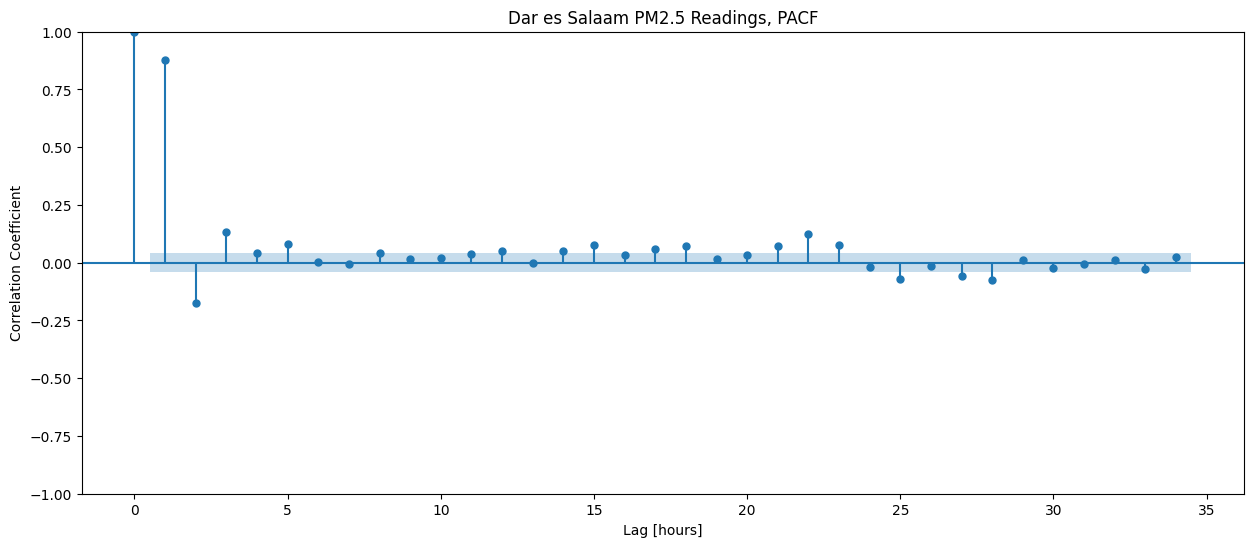

In [86]:
fig, ax = plt.subplots(figsize=(15, 6))

# Use ax=ax in your plot
plot_pacf(y, ax=ax)
ax.set_xlabel("Lag [hours]")
ax.set_ylabel("Correlation Coefficient")
ax.set_title("Dar es Salaam PM2.5 Readings, PACF")

## Split

**Task 3.5.9**

In [87]:
# Calculate the cutoff index for a 90/10 split
cutoff_test = int(len(y) * 0.9)

# Slice the data into training and testing sets
y_train = y.iloc[:cutoff_test]
y_test = y.iloc[cutoff_test:]
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

y_train shape: (1944,)
y_test shape: (216,)


# Build Model

## Baseline

**Task 3.5.10**

In [88]:
# Calculate the mean of the training data
y_train_mean = y_train.mean()

# Create a baseline prediction series filled with the mean value
y_pred_baseline = [y_train_mean] * len(y_train)

# Calculate the baseline Mean Absolute Error
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)

print("Mean P2 Reading:", y_train_mean)
print("Baseline MAE:", mae_baseline)

Mean P2 Reading: 8.57142319061077
Baseline MAE: 4.053101181299159


## Iterate

**Task 3.5.11**

<div class="alert alert-block alert-info">
    <p><b>Tip:</b> In this task, you'll need to combine the model you learned about in <b>Task 3.3.8</b> with the hyperparameter tuning technique you learned in <b>Task 3.4.9</b>.</p>
</div>

In [92]:
# Create range to test different lags
p_params = range(1, 31)

# Create empty list to hold mean absolute error scores
maes = []

# Iterate through all values of p in `p_params`
for p in p_params:
    # Build model
    model = AutoReg(y_train, lags=p).fit()

    # Make predictions on training data, dropping null values caused by lag
    y_pred = model.predict().dropna()

    # Calculate mean absolute error for training data vs predictions
    mae = mean_absolute_error(y_train.iloc[p:], y_pred)

    # Append `mae` to list `maes`
    maes.append(mae)

# Put list `maes` into Series with index `p_params`
mae_series = pd.Series(maes, name="mae", index=p_params)

# Inspect head of Series
mae_series

1     1.059376
2     1.045182
3     1.032489
4     1.032147
5     1.031022
6     1.026948
7     1.023510
8     1.022944
9     1.022321
10    1.022058
11    1.018001
12    1.018568
13    1.019006
14    1.018080
15    1.018818
16    1.021036
17    1.021398
18    1.021820
19    1.020472
20    1.019727
21    1.017981
22    1.017824
23    1.014569
24    1.013427
25    1.010657
26    1.010285
27    1.010619
28    1.010287
29    1.012046
30    1.016535
Name: mae, dtype: float64

**Task 3.5.12**

In [94]:
# Identify the hyperparameter p that gives the lowest MAE
best_p = mae_series.idxmin()

# Train best_model using the best hyperparameter value
best_model = AutoReg(y_train, lags=best_p).fit()

**Task 3.5.13**

In [99]:
# Calculate the training residuals for best_model
y_train_resid = best_model.resid

# Assign the name "residuals" to your Series
y_train_resid.name = "residuals"
y_train_resid.head()

timestamp
2018-01-02 05:00:00+03:00   -0.412913
2018-01-02 06:00:00+03:00    1.484934
2018-01-02 07:00:00+03:00    1.672359
2018-01-02 08:00:00+03:00   -0.368030
2018-01-02 09:00:00+03:00   -0.536868
Freq: H, Name: residuals, dtype: float64

In [100]:
y_train_resid

timestamp
2018-01-02 05:00:00+03:00   -0.412913
2018-01-02 06:00:00+03:00    1.484934
2018-01-02 07:00:00+03:00    1.672359
2018-01-02 08:00:00+03:00   -0.368030
2018-01-02 09:00:00+03:00   -0.536868
                               ...   
2018-03-22 22:00:00+03:00   -0.157974
2018-03-22 23:00:00+03:00   -1.114870
2018-03-23 00:00:00+03:00    0.495103
2018-03-23 01:00:00+03:00    0.030638
2018-03-23 02:00:00+03:00    2.401650
Freq: H, Name: residuals, Length: 1918, dtype: float64

<div class="alert alert-info" role="alert">
  <strong>Slight Code Change</strong>

In the following task, you'll notice a small change in how plots are created compared to what you saw in the lessons.
While the lessons use the global matplotlib method like <code>plt.plot(...)</code>, in this task, you are expected to use the object-oriented (OOP) API instead.
This means creating your plots using <code>fig, ax = plt.subplots()</code> and then calling plotting methods on the <code>ax</code> object, such as <code>ax.plot(...)</code>, <code>ax.hist(...)</code>, or <code>ax.scatter(...)</code>.

If you're using pandas’ or seaborn’s built-in plotting methods (like <code>df.plot()</code> or <code>sns.lineplot()</code>), make sure to pass the <code>ax=ax</code> argument so that the plot is rendered on the correct axes.

This approach is considered best practice and will be used consistently across all graded tasks that involve matplotlib.
</div>


**Task 3.5.14**

Text(0.5, 1.0, 'Best Model, Training Residuals')

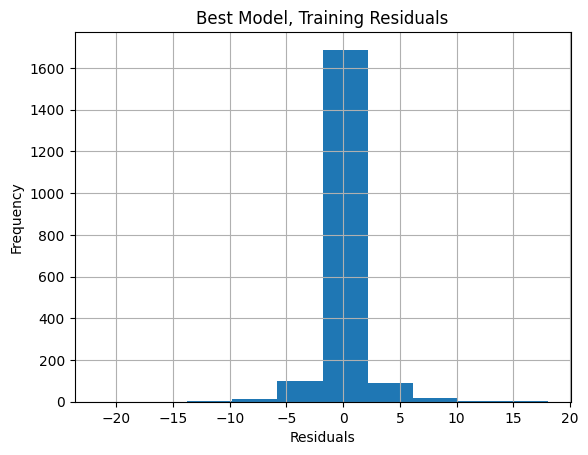

In [102]:
# Plot histogram of residuals
fig, ax = plt.subplots()

# Use ax=ax in your plot
y_train_resid.hist(ax=ax)
ax.set_xlabel("Residuals")
ax.set_ylabel("Frequency")
ax.set_title("Best Model, Training Residuals")


**Task 3.5.15**

Text(0.5, 1.0, 'Dar es Salaam, Training Residuals ACF')

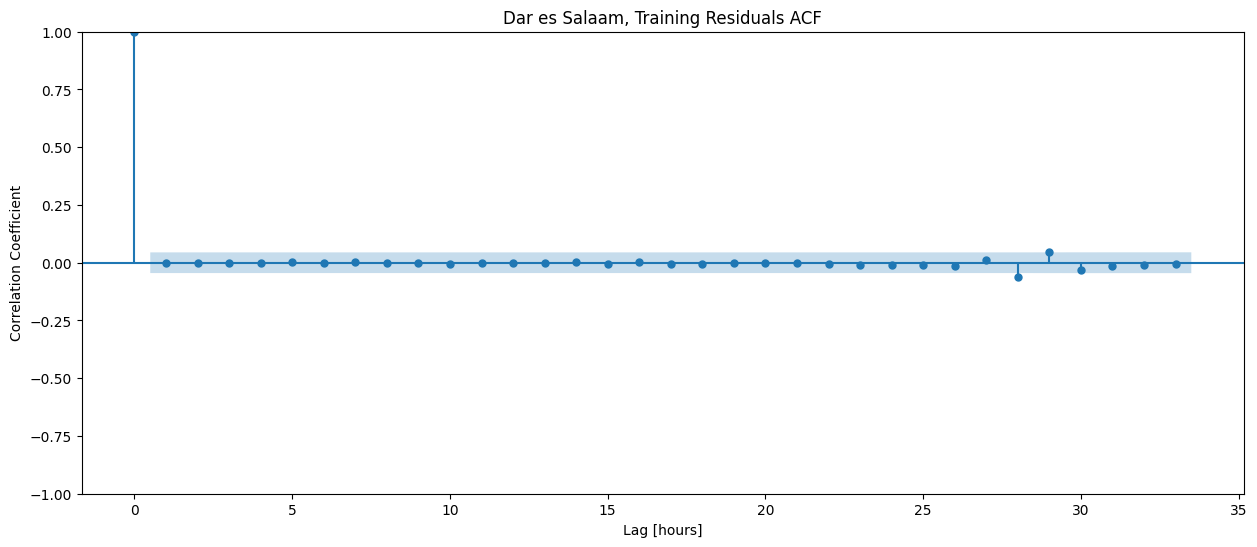

In [104]:
fig, ax = plt.subplots(figsize=(15, 6))

# Use ax=ax in your plot
plot_acf(y_train_resid, ax=ax)
ax.set_xlabel("Lag [hours]")
ax.set_ylabel("Correlation Coefficient")
ax.set_title("Dar es Salaam, Training Residuals ACF")

## Evaluate

**Task 3.5.16**

In [106]:
# Initialize history with training data and an empty list for predictions
history = y_train.copy()
y_pred_wfv = []

# Perform walk-forward validation loop
for i in range(len(y_test)):
    # Build and fit the AutoReg model on current history
    model = AutoReg(history, lags=best_p).fit()
    
    # Forecast the next point (1 step ahead)
    next_pred = model.forecast(steps=1).iloc[0]
    y_pred_wfv.append(next_pred)
    
    # Append the actual test value to history for the next iteration
    history = pd.concat([history, y_test.iloc[[i]]])

# Convert the predictions list into a pandas Series with proper format
y_pred_wfv = pd.Series(y_pred_wfv, index=y_test.index)
y_pred_wfv.name = "prediction"
y_pred_wfv.index.name = "timestamp"
y_pred_wfv.head()

timestamp
2018-03-23 03:00:00+03:00    10.414744
2018-03-23 04:00:00+03:00     8.269589
2018-03-23 05:00:00+03:00    15.178677
2018-03-23 06:00:00+03:00    33.475398
2018-03-23 07:00:00+03:00    39.571363
Freq: H, Name: prediction, dtype: float64

In [107]:
y_pred_wfv

timestamp
2018-03-23 03:00:00+03:00    10.414744
2018-03-23 04:00:00+03:00     8.269589
2018-03-23 05:00:00+03:00    15.178677
2018-03-23 06:00:00+03:00    33.475398
2018-03-23 07:00:00+03:00    39.571363
                               ...    
2018-03-31 22:00:00+03:00     6.939370
2018-03-31 23:00:00+03:00     8.114680
2018-04-01 00:00:00+03:00     5.710798
2018-04-01 01:00:00+03:00     9.133960
2018-04-01 02:00:00+03:00    28.946615
Freq: H, Name: prediction, Length: 216, dtype: float64

**Task 3.5.17**

In [124]:
# Enter y_pred_wfv at ... (Ellipsis) to see the test mean absolute error
# Calculate tge test neab absolute error
test_mae = mean_absolute_error(y_test, y_pred_wfv)

# Print the final test MAE (Fixed the missing closing parenthesis)
print("Test MAE (walk forward validation):", round(test_mae, 2))

Test MAE (walk forward validation): 3.97


# Communicate Results

**Task 3.5.18**

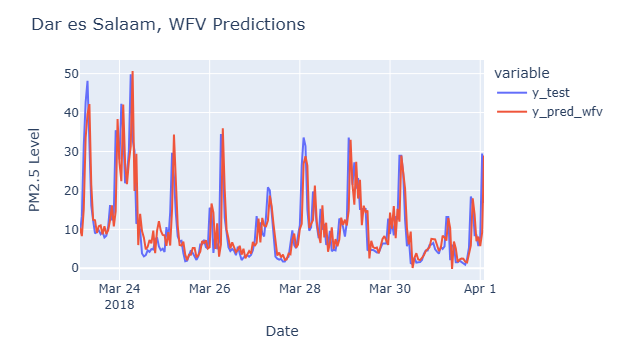

In [125]:
# Put the test data and predictions into a DataFrame
df_pred_test = pd.DataFrame(
    {"y_test": y_test, "y_pred_wfv": y_pred_wfv}
)

# Plot the dataframe using plotly express line plot
fig = px.line(df_pred_test)

# Update layout with required titles and labels
fig.update_layout(
    title="Dar es Salaam, WFV Predictions",
    xaxis_title="Date",
    yaxis_title="PM2.5 Level",
)

# Render the interactive plot
fig.show()

---
Copyright 2024 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.


In [126]:
import base64
from IPython.display import HTML

# Read the file and encode it to base64 to bypass platform restrictions
with open("035-assignment.ipynb", "rb") as f:
    b64 = base64.b64encode(f.read()).decode()

# Create a forced browser download link using raw data URI
download_html = f'''
<a href="data:application/json;base64,{b64}" download="Air-Quality-Forecasting-Dar-es-Salaam.ipynb" 
   style="background-color: #4CAF50; color: white; padding: 12px 20px; text-decoration: none; 
          font-weight: bold; border-radius: 4px; display: inline-block;">
   ⬇️ FORCE DOWNLOAD FOR GITHUB
</a>
'''

display(HTML(download_html))